<a href="https://colab.research.google.com/github/thejclan/LegoClassification/blob/main/LegoClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
ModuleNotFoundError: No module named 'h5py'

In [ ]:
#匯入資料集
path = 'gdrive/MyDrive/卷積神經網路/LEGO/'

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive') # 授權存取 google drive 中的檔案
index_df = pd.read_csv('/content/gdrive/MyDrive/卷積神經網路/LEGO/index.csv')
index_df.head()

Mounted at /content/gdrive


,path,class_id
0,marvel/0001/001.jpg,1
1,marvel/0001/002.jpg,1
2,marvel/0001/003.jpg,1
3,marvel/0001/004.jpg,1
4,marvel/0001/005.jpg,1


In [ ]:
meta_df = pd.read_csv(path + 'metadata.csv', sep=",", encoding='cp1252')
meta_df.head()

,class_id,lego_ids,lego_names,minifigure_name
0,1,[76115],['Spider Mech vs. Venom'],SPIDER-MAN
1,2,[76115],['Spider Mech vs. Venom'],VENOM
2,3,[76115],['Spider Mech vs. Venom'],AUNT MAY
3,4,[76115],['Spider Mech vs. Venom'],GHOST SPIDER
4,5,[75208],"[""Yoda's Hut""]",YODA


In [ ]:
data_df = pd.merge(index_df, meta_df[['class_id', 'minifigure_name']], on = 'class_id')
data_df

,path,class_id,minifigure_name
0,marvel/0001/001.jpg,1,SPIDER-MAN
1,marvel/0001/002.jpg,1,SPIDER-MAN
2,marvel/0001/003.jpg,1,SPIDER-MAN
3,marvel/0001/004.jpg,1,SPIDER-MAN
4,marvel/0001/005.jpg,1,SPIDER-MAN
...,...,...,...
366,star-wars/0017/006.jpg,38,BOBA FETT
367,star-wars/0017/007.jpg,38,BOBA FETT
368,star-wars/0017/008.jpg,38,BOBA FETT
369,star-wars/0017/009.jpg,38,BOBA FETT


In [ ]:
data_df.isnull().sum()

path               0
class_id           0
minifigure_name    0
dtype: int64

In [ ]:
#將資料分為訓練集、驗證集
train_set = data_df.sample(frac=0.52)
train_set

,path,class_id,minifigure_name
81,star-wars/0004/006.jpg,8,MACE WINDU
326,star-wars/0013/003.jpg,34,DARTH VADER
224,marvel/0012/001.jpg,24,OUTRIDER 1
221,marvel/0011/008.jpg,23,CAPTAIN AMERICA
225,marvel/0012/002.jpg,24,OUTRIDER 1
...,...,...,...
32,marvel/0004/003.jpg,4,GHOST SPIDER
202,marvel/0009/011.jpg,21,YELENA BELOVA
362,star-wars/0017/002.jpg,38,BOBA FETT
137,marvel/0005/003.jpg,15,MYSTERIO


In [ ]:
validation_set = data_df[~data_df.index.isin(train_set.index)]
validation_set

,path,class_id,minifigure_name
2,marvel/0001/003.jpg,1,SPIDER-MAN
3,marvel/0001/004.jpg,1,SPIDER-MAN
4,marvel/0001/005.jpg,1,SPIDER-MAN
5,marvel/0001/006.jpg,1,SPIDER-MAN
8,marvel/0001/009.jpg,1,SPIDER-MAN
...,...,...,...
360,star-wars/0016/009.jpg,37,OBI-WAN KENOBI
361,star-wars/0017/001.jpg,38,BOBA FETT
364,star-wars/0017/004.jpg,38,BOBA FETT
365,star-wars/0017/005.jpg,38,BOBA FETT


In [ ]:
import cv2
import numpy as np
#training data preprocessing
#converted the pixels of the image data to array
train_Data = np.zeros((train_set.shape[0], 224, 224, 3))

In [ ]:
for i in range (train_set.shape[0]):
  image = cv2.imread('gdrive/MyDrive/卷積神經網路/LEGO/' + train_set["path"].values[i])

  #converting bgr to rgb
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  #resizing image
  image = cv2.resize(image, (224, 224))
  #normalizing pixel values to [0, 1]
  train_Data[i] = image / 255.0

trainLabel = np.array(train_set["class_id"])-1

In [ ]:
validation_Data = np.zeros((validation_set.shape[0], 224, 224, 3))

for i in range (validation_set.shape[0]):
  image = cv2.imread('gdrive/MyDrive/卷積神經網路/LEGO/' + validation_set["path"].values[i])

  #converting bgr to rgb
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  #resizing image
  image = cv2.resize(image, (224, 224))
  #normalizing pixel values to [0, 1]
  validation_Data[i] = image / 255.0

validationLabel = np.array(validation_set["class_id"])-1

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import applications, models, optimizers, layers, callbacks
from tensorflow.keras.layers import Dropout, Dense
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

dense_net = tf.keras.applications.DenseNet121()
dense_net_layer = Dropout(0.5)(dense_net.layers[-2].output)
number_of_classes = len(data_df['class_id'].unique())
last_layer = Dense(number_of_classes, activation = "softmax")(dense_net_layer)
model = Model(dense_net.input, last_layer)

In [ ]:
#優化器Adam
model.compile(loss = 'sparse_categorical_crossentropy',
              optimizer = Adam(0.0001),
              metrics = ['accuracy'])
#儲存點
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint(filepath = 'model.h5', monitor = "val_accuracy", save_best_only = True, verbose = 1)

In [ ]:
#模型訓練
hist = model.fit(
    train_Data,
    trainLabel,
    epochs = 10,
    validation_data = (validation_Data, validationLabel),
    shuffle = True,
    batch_size = 4,
    callbacks = checkpoint
)

Epoch 1/10
49/49 [==============================] - ETA: 0s - loss: 4.2432 - accuracy: 0.0570
Epoch 1: val_accuracy improved from -inf to 0.10674, saving model to model.h5
49/49 [==============================] - 30s 207ms/step - loss: 4.2432 - accuracy: 0.0570 - val_loss: 3.7306 - val_accuracy: 0.1067
Epoch 2/10
49/49 [==============================] - ETA: 0s - loss: 2.7778 - accuracy: 0.2073
Epoch 2: val_accuracy improved from 0.10674 to 0.20225, saving model to model.h5
49/49 [==============================] - 6s 119ms/step - loss: 2.7778 - accuracy: 0.2073 - val_loss: 3.1076 - val_accuracy: 0.2022
Epoch 3/10
49/49 [==============================] - ETA: 0s - loss: 2.0972 - accuracy: 0.4041
Epoch 3: val_accuracy improved from 0.20225 to 0.38764, saving model to model.h5
49/49 [==============================] - 5s 108ms/step - loss: 2.0972 - accuracy: 0.4041 - val_loss: 2.5055 - val_accuracy: 0.3876
Epoch 4/10
48/49 [============================>.] - ETA: 0s - loss: 1.4209 - accurac

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


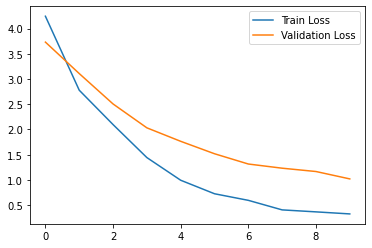

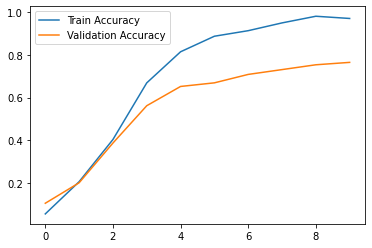

In [ ]:
import matplotlib.pyplot as plt
print(hist.history.keys())
plt.plot(hist.history["loss"], label = "Train Loss")
plt.plot(hist.history["val_loss"], label = "Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist.history["accuracy"], label = "Train Accuracy")
plt.plot(hist.history["val_accuracy"], label = "Validation Accuracy")
plt.legend()
plt.show()